In [1]:
import uproot as up
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection
import scipy.optimize as scp
%matplotlib inline


In [2]:
file=up.open("/home/rice/Projects/DUNE_Opticks/Build_Test/work/100k_17-3Voxel_Comparison.root")
#file=up.open("/home/rice/Projects/DUNE_Opticks/Build_Test/work/Photonlibrary_dune10kt_1x2x6_opticks_v6.root")
file.keys()

['generator;1',
 'generator/PhotonsGenerated;765',
 'generator/PhotonsGenerated;764',
 'largeant;1',
 'largeant/electronsPerStep;1',
 'largeant/photonsPerStep;1',
 'largeant/energyPerStep;1',
 'largeant/stepSize;1',
 'largeant/electronsPerLength;1',
 'largeant/photonsPerLength;1',
 'largeant/electronsPerEDep;1',
 'largeant/photonsPerEDep;1',
 'largeant/electronsVsPhotons;1',
 'opticks;1',
 'opticks/photon_gen;1184',
 'opticks/photon_gen;1183',
 'opticks/OpticksHits;34',
 'opticks/OpticksHits;33',
 'opticks/Visibilities;1',
 'pmtresponse;1',
 'pmtresponse/AllPhotons;1',
 'pmtresponse/DetectedPhotons;1',
 'pmtresponse/OpDets;1',
 'pmtresponse/OpDetEvents;1',
 'pmtresponse/PhotonLibraryData;1',
 'pmtresponse/NVoxels;1',
 'pmtresponse/NChannels;1',
 'pmtresponse/MinX;1',
 'pmtresponse/MinY;1',
 'pmtresponse/MinZ;1',
 'pmtresponse/MaxX;1',
 'pmtresponse/MaxY;1',
 'pmtresponse/MaxZ;1',
 'pmtresponse/StepX;1',
 'pmtresponse/StepY;1',
 'pmtresponse/StepZ;1',
 'pmtresponse/NDivX;1',
 'pmtrespon

In [3]:
def Plot2D_JointPlot(valO,ValG4,FileName,Title,Binsize=200,histBin=500,isPlottext=False,isHistType="numpy"):
    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={"x(mm)":ValG4[0],"y(mm)":ValG4[1]}
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x="x(mm)", y="y(mm)", kind='hist',bins=[lins1X,lins1Y],marginal_kws={"bins":lins1X,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    #plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    g.ax_joint.tick_params(axis='both', which='major', labelsize=25) 
    g.ax_joint.set_xlabel("x (mm)",fontsize=25)
    g.ax_joint.set_ylabel("y (mm)",fontsize=25)
    if(isPlottext):
        binX=np.linspace(np.min(ValG4[0]),np.max(ValG4[0]),histBin)
        binY=np.linspace(np.min(ValG4[1]),np.max(ValG4[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            fitx=FitHist1D(x,None,"x","blue",0.5)
            fity=FitHist1D(y,None,"y","red",0.5)
        else:
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            x=plt.hist(ValG4[0], bins=lins1X)
            y=np.histogram(ValG4[1], bins=lins1Y)
            fitx=FitHist1D(x,plt,"x","blue",0.5)
            fity=FitHist1D(y,plt,"y","red",0.5)
            plt.xlim(-5,5)
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)

        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=20)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=20)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="right",fontsize=25)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x="x(mm)",y= "y(mm)" ,kind='hist',cmap="viridis",bins=[lins1X,lins1Y],marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});
    g.ax_joint.tick_params(axis='both', which='major', labelsize=25)    
    g.ax_joint.set_xlabel("x (mm)",fontsize=25)
    g.ax_joint.set_ylabel("y (mm)",fontsize=25)
    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)
    #plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(valO[0]),np.max(valO[0]),histBin)
        binY=np.linspace(np.min(valO[1]),np.max(valO[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,None,"x","red",0.5)
            fity=FitHist1D(y,None,"y","green",0.5)
        else:
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,plt,"x","red",0.5)
            fity=FitHist1D(y,plt,"y","green",0.5)
            plt.xlim(-5,5)


        
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)

        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='red', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=20)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=20)
    
    plt.suptitle(Title[0],fontweight="bold",ha="right",fontsize=25)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    del g
    
def Plot1D_KDE(valO,ValG4,FileName,Title,Binsize=200,labelx="x",isPlottext=False,isHistType="numpy",opacity=1,fontsize=30,width=5,lbls=["Geant4","Opticks"],tp="diff"):
    maXX = np.max(np.array([np.max(ValG4),np.max(valO)]))
    miNX = np.min(np.array([np.min(ValG4),np.min(valO)]))
    lins1X = np.linspace(miNX,maXX,Binsize)
    fig, ax = plt.subplots(2, 1, figsize=(25, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    x = 0
    y = 0
    if(isPlottext):
        if(isHistType=="numpy"):
            x = np.histogram(ValG4, bins=lins1X)
        else:
            x = plt.hist(ValG4, bins=lins1X)
        h1=ax[0].hist(ValG4,color="red",label=lbls[0],bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    else:
        #sns.histplot(data=G4Dict,x=lbl,color="orange",label="Geant4",bins=Binsz,kde=False,element="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
        h1=ax[0].hist(ValG4,color="red",label=lbls[0],bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    
    x=0
    y=0
    fitx=0
    fity=0
    
    if(isPlottext):
        binX = np.linspace(np.min(valO[0]) , np.max(valO[0]) , Binsize)
        if(isHistType=="numpy"):
            x = np.histogram(valO[0], bins=binX)
        else:
            x = np.histogram(valO[0], bins=binX)
        h2=ax[0].hist(valO,color="green",label=lbls[1],bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);
    else:    
        #sns.histplot(data=OpticksDict,x=lbl,color="blue",label="Opticks",bins=Binsz,kde=False,element="step",fill=False,linestyle="--",linewidth=width,alpha=opacity)
        h2=ax[0].hist(valO,color="green",label=lbls[1],bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);

    #Ratio Plot    
    # Calculate histogram counts for ratio plot - MUST use same bins
    counts1,bin_edges,_ = h1
    counts2,_,_ = h2 # Use the same bin_edges

    # Calculate bin centers for plotting the ratio
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    numerator_val = 0
    combinedarray = 0
    denominator_val = 0
    result=[]
    res_err=[]
    label=""
    ylabel=""
    xlabel=""
   
    
    if(tp == "diff"):
        label="Difference"
        ylabel="diff / max"
        xlabel=labelx
        numerator_val = counts2 - counts1
        combinedarray = np.concatenate((counts1, counts2))
        denominator_val = 1#np.max(combinedarray)
        
        eps = 1e-12
        numerator_val = np.where(np.abs(numerator_val) < eps, eps, numerator_val)
        denominator_val = np.where(np.abs(denominator_val) < eps, eps, denominator_val)
        result  = numerator_val / denominator_val
        error_numerator = np.sqrt(counts1 + counts2)
        error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
        res_err = np.abs(result) * np.sqrt((error_numerator / numerator_val)**2 +(error_denominator / denominator_val)**2)        
    elif( tp == "ratio"):
        label="Ratio G4/Opticks"
        ylabel="Ratio"
        xlabel=labelx
        # Poisson errors (or replace with your own errors)
        err1 = np.sqrt(counts1)
        err2 = np.sqrt(counts2)

        # ratio
        result  = counts2 / counts1
        # propagated error
        res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)
    if(len(result)<1):
        print (f"Check type {tp}, vector does not have any element")
        return
 
    #error_numerator = np.sqrt(counts1 + counts2)
    #error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
    
  

    # Use scientific notation for the axis 
    ax[0].ticklabel_format(axis='y', style='sci', scilimits=(4,4))
    ax[0].tick_params(axis='both',which="major",labelsize=fontsize+10)
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)


    ax[0].set_ylabel("Frequency",fontsize=fontsize+10)
    #ax[0].set_xlabel(lbl,fontsize=fontsize+10)
    ax[0].yaxis.get_offset_text().set_size(fontsize+10) # Adjust the font size here
    ax[0].legend(fontsize=fontsize)   
    ax[0].set_title(Title,fontweight="bold",ha="center",fontsize=fontsize+20)
    ax[0].semilogy()
    
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    
    print (f" Size Bin_Centers is {len(bin_centers)}")
    print (f" Size result {len(result)} min, max {np.max(result)} , {np.min(result)}")    
    print (f" Size res_err {len(res_err)} min, max {np.max(res_err)} , {np.min(res_err)}")    
    
    #ax[1].plot(bin_centers, ratio, marker='o', linestyle='-', color='black', markersize=5)
    ax[1].errorbar(bin_centers, result, yerr=res_err, fmt='o', color='black',
                    markersize=5, capsize=3, elinewidth=1, label=label) # fmt='o' for points
    ax[1].axhline(1, color='grey', linestyle='--', linewidth=1)
    ax[1].set_xlabel(xlabel,fontsize=fontsize+10)
    ax[1].set_ylabel(ylabel,fontsize=(fontsize+10))
    ax[1].grid(True, linestyle=':', alpha=0.6)
    #ax[1].set_ylim(-np.max(res_err),np.max(res_err))
    #print(f"result {result}")
    #print(f"res_err {res_err}")
    #ax[1].semilogy()
    #ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0.01,0.01))
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)
        
    
def FitHist1D(hist,ax,label,clr,ap,width=3,linstyle="-"):
    ## Locate Min and Max
    MinAndMaxMask=(hist[0]>=(np.mean(hist[0])*0.1)) & (hist[0]<=np.max(hist[0])*0.9)
    
    initials=(np.max(hist[0]),np.mean(hist[1][:-1][MinAndMaxMask]),np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    #initials=(np.max(hist[0]),0,np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    print(f"Initials {initials}")
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials,maxfev=5000)
    String_=label+r'$\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    if(ax):
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,linestyle=linstyle,alpha=ap,linewidth=width)
    FitValues={"Amp":round(fit[0][0],2),"u":round(fit[0][1],2),"sigma":abs(round(fit[0][2],2)),"offset":round(fit[0][3],2)}
    print(FitValues)
    return FitValues    

In [4]:

file["pmtresponse/DetectedPhotons"].keys()

['EventID', 'Wavelength', 'OpChannel', 'Time']

In [5]:
G4Time=file["pmtresponse/DetectedPhotons/Time"].array().to_numpy()
G4Timev2=file["pmtresponse/OpDets/Time"].array().to_numpy()
G4Wavelength=file["pmtresponse/DetectedPhotons/Wavelength"].array().to_numpy()

In [6]:

G4=file["pmtresponse/PhotonLibraryData"]
print(G4.keys())

G4Voxel=G4["Voxel"].array().to_numpy()
G4SensorID=G4["OpChannel"].array().to_numpy()
G4Visibility=G4["Visibility"].array().to_numpy()

['Voxel', 'OpChannel', 'Visibility']


In [7]:

#f=up.open("/home/rice/Projects/DUNE_Opticks/OlderG4OpticksGDML/dune10kt_v5_refactored_1x2x6_e_3GeV.root")
O=file["opticks/Visibilities"]
print(O.keys())
OVoxel=O["Voxel"].array().to_numpy()
OSensorID=O["OptDetID"].array().to_numpy()
OVisibility=O["Visibility"].array().to_numpy()
OhitSensID=file["opticks/OpticksHits/sensor_id"].array().to_numpy()

['Voxel', 'OptDetID', 'Visibility']


In [8]:
print(len(G4Voxel))
print(len(OVoxel))
print(1-len(G4Voxel)/len(OVoxel))


1205256
1150660
-0.04744755183981364


Text(0.5, 0, 'Visibilities')

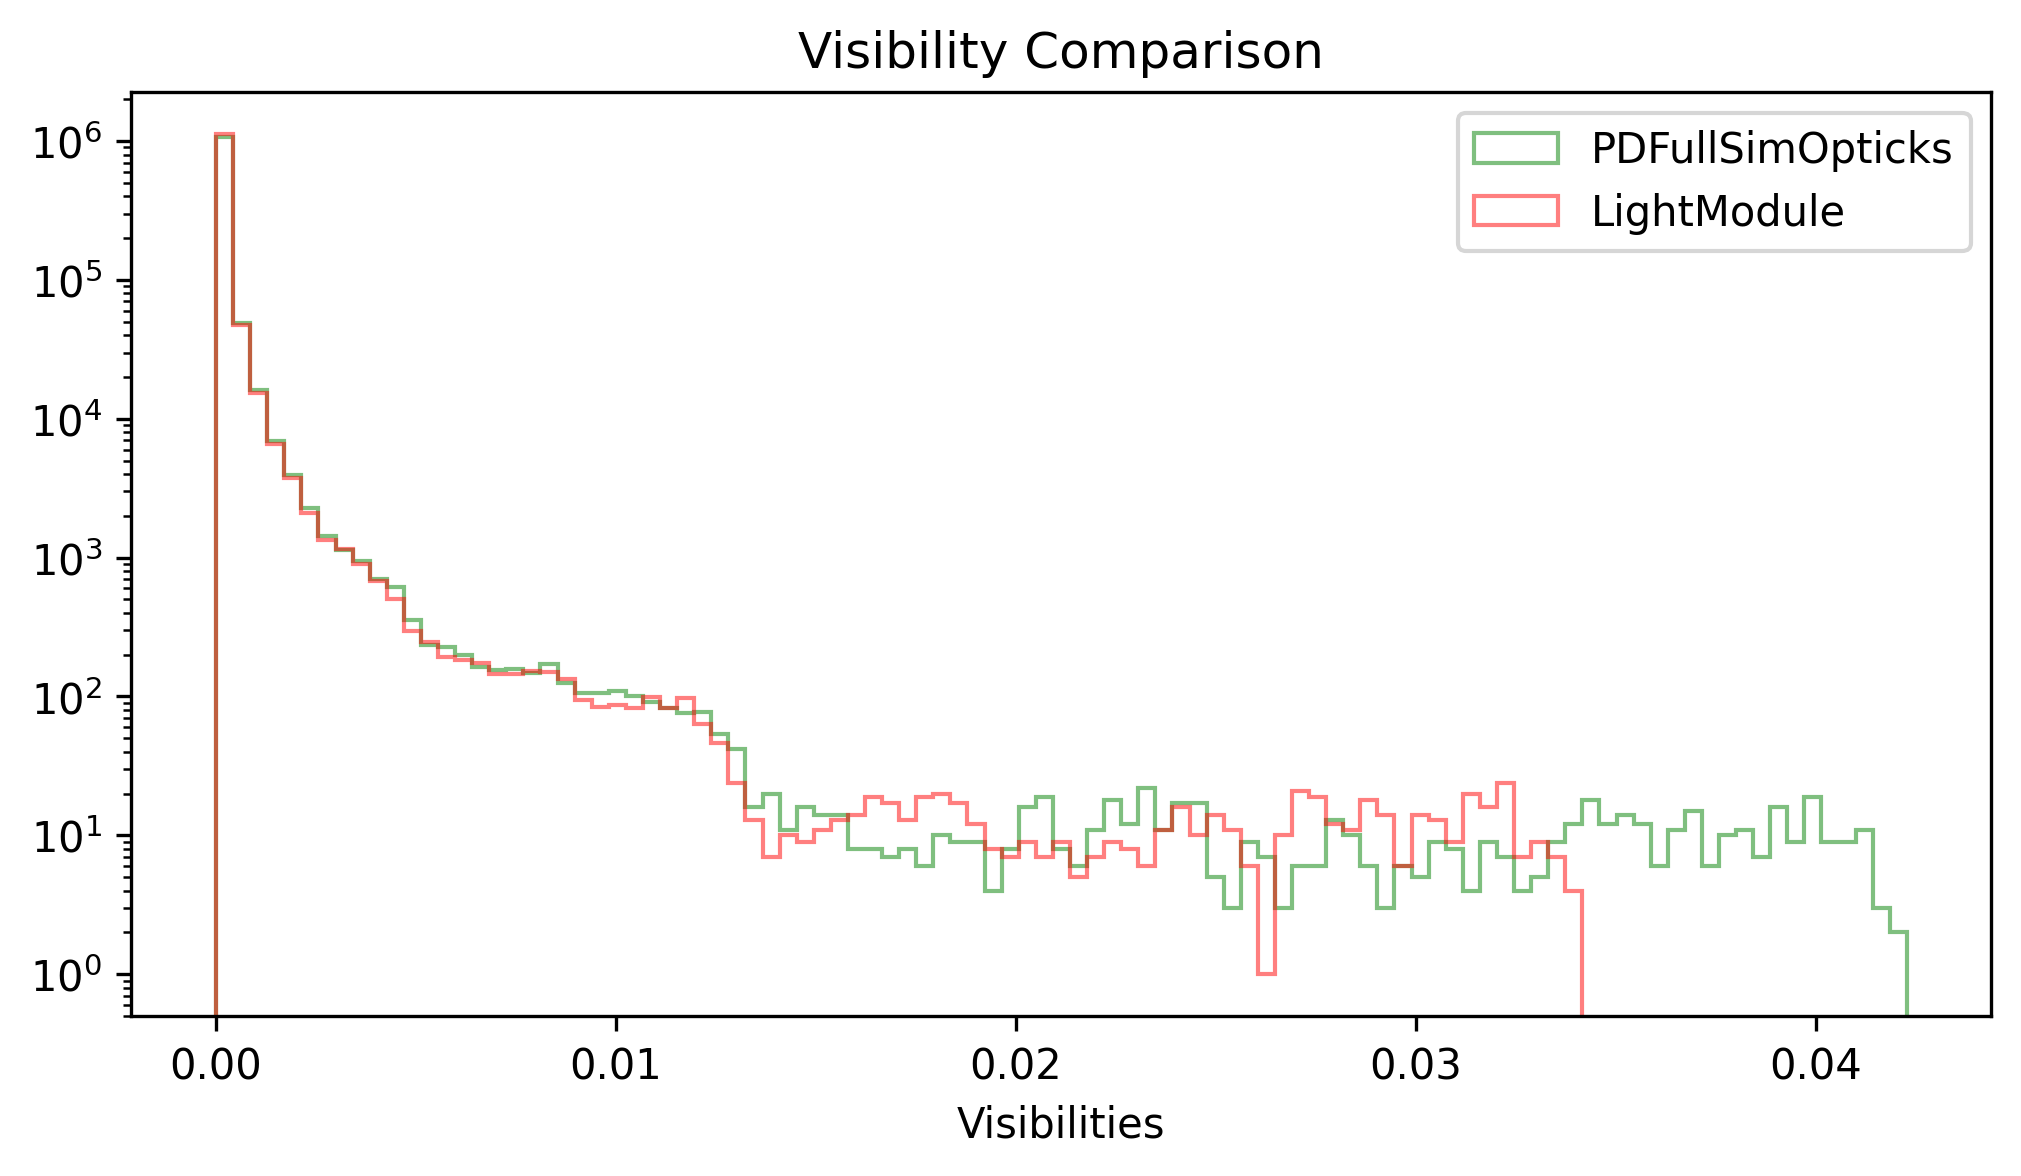

In [9]:
vismin = min(OVisibility.min(), G4Visibility.min())
vismax = max(OVisibility.max(), G4Visibility.max())
xbins = np.linspace(vismin , vismax , 100)

plt.figure(figsize=(8,4),dpi=300)
plt.title("Visibility Comparison")
h1=plt.hist(OVisibility, bins=xbins, alpha=0.5, label="PDFullSimOpticks",histtype="step",color="green")
h2=plt.hist(G4Visibility, bins=xbins, alpha=0.5, label="LightModule",histtype="step",color="red")
plt.legend()
#plt.loglog()
plt.semilogy()
plt.xlabel("Visibilities")

In [10]:
result=h2[0]/h1[0]

[]

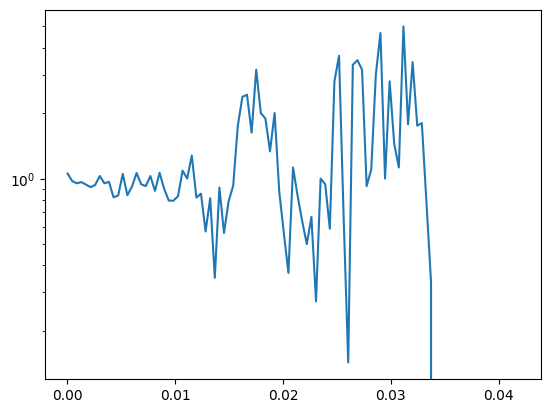

In [11]:
plt.plot(h2[1][:-1],result)
plt.semilogy()

Text(0.5, 0, 'Sensor ID')

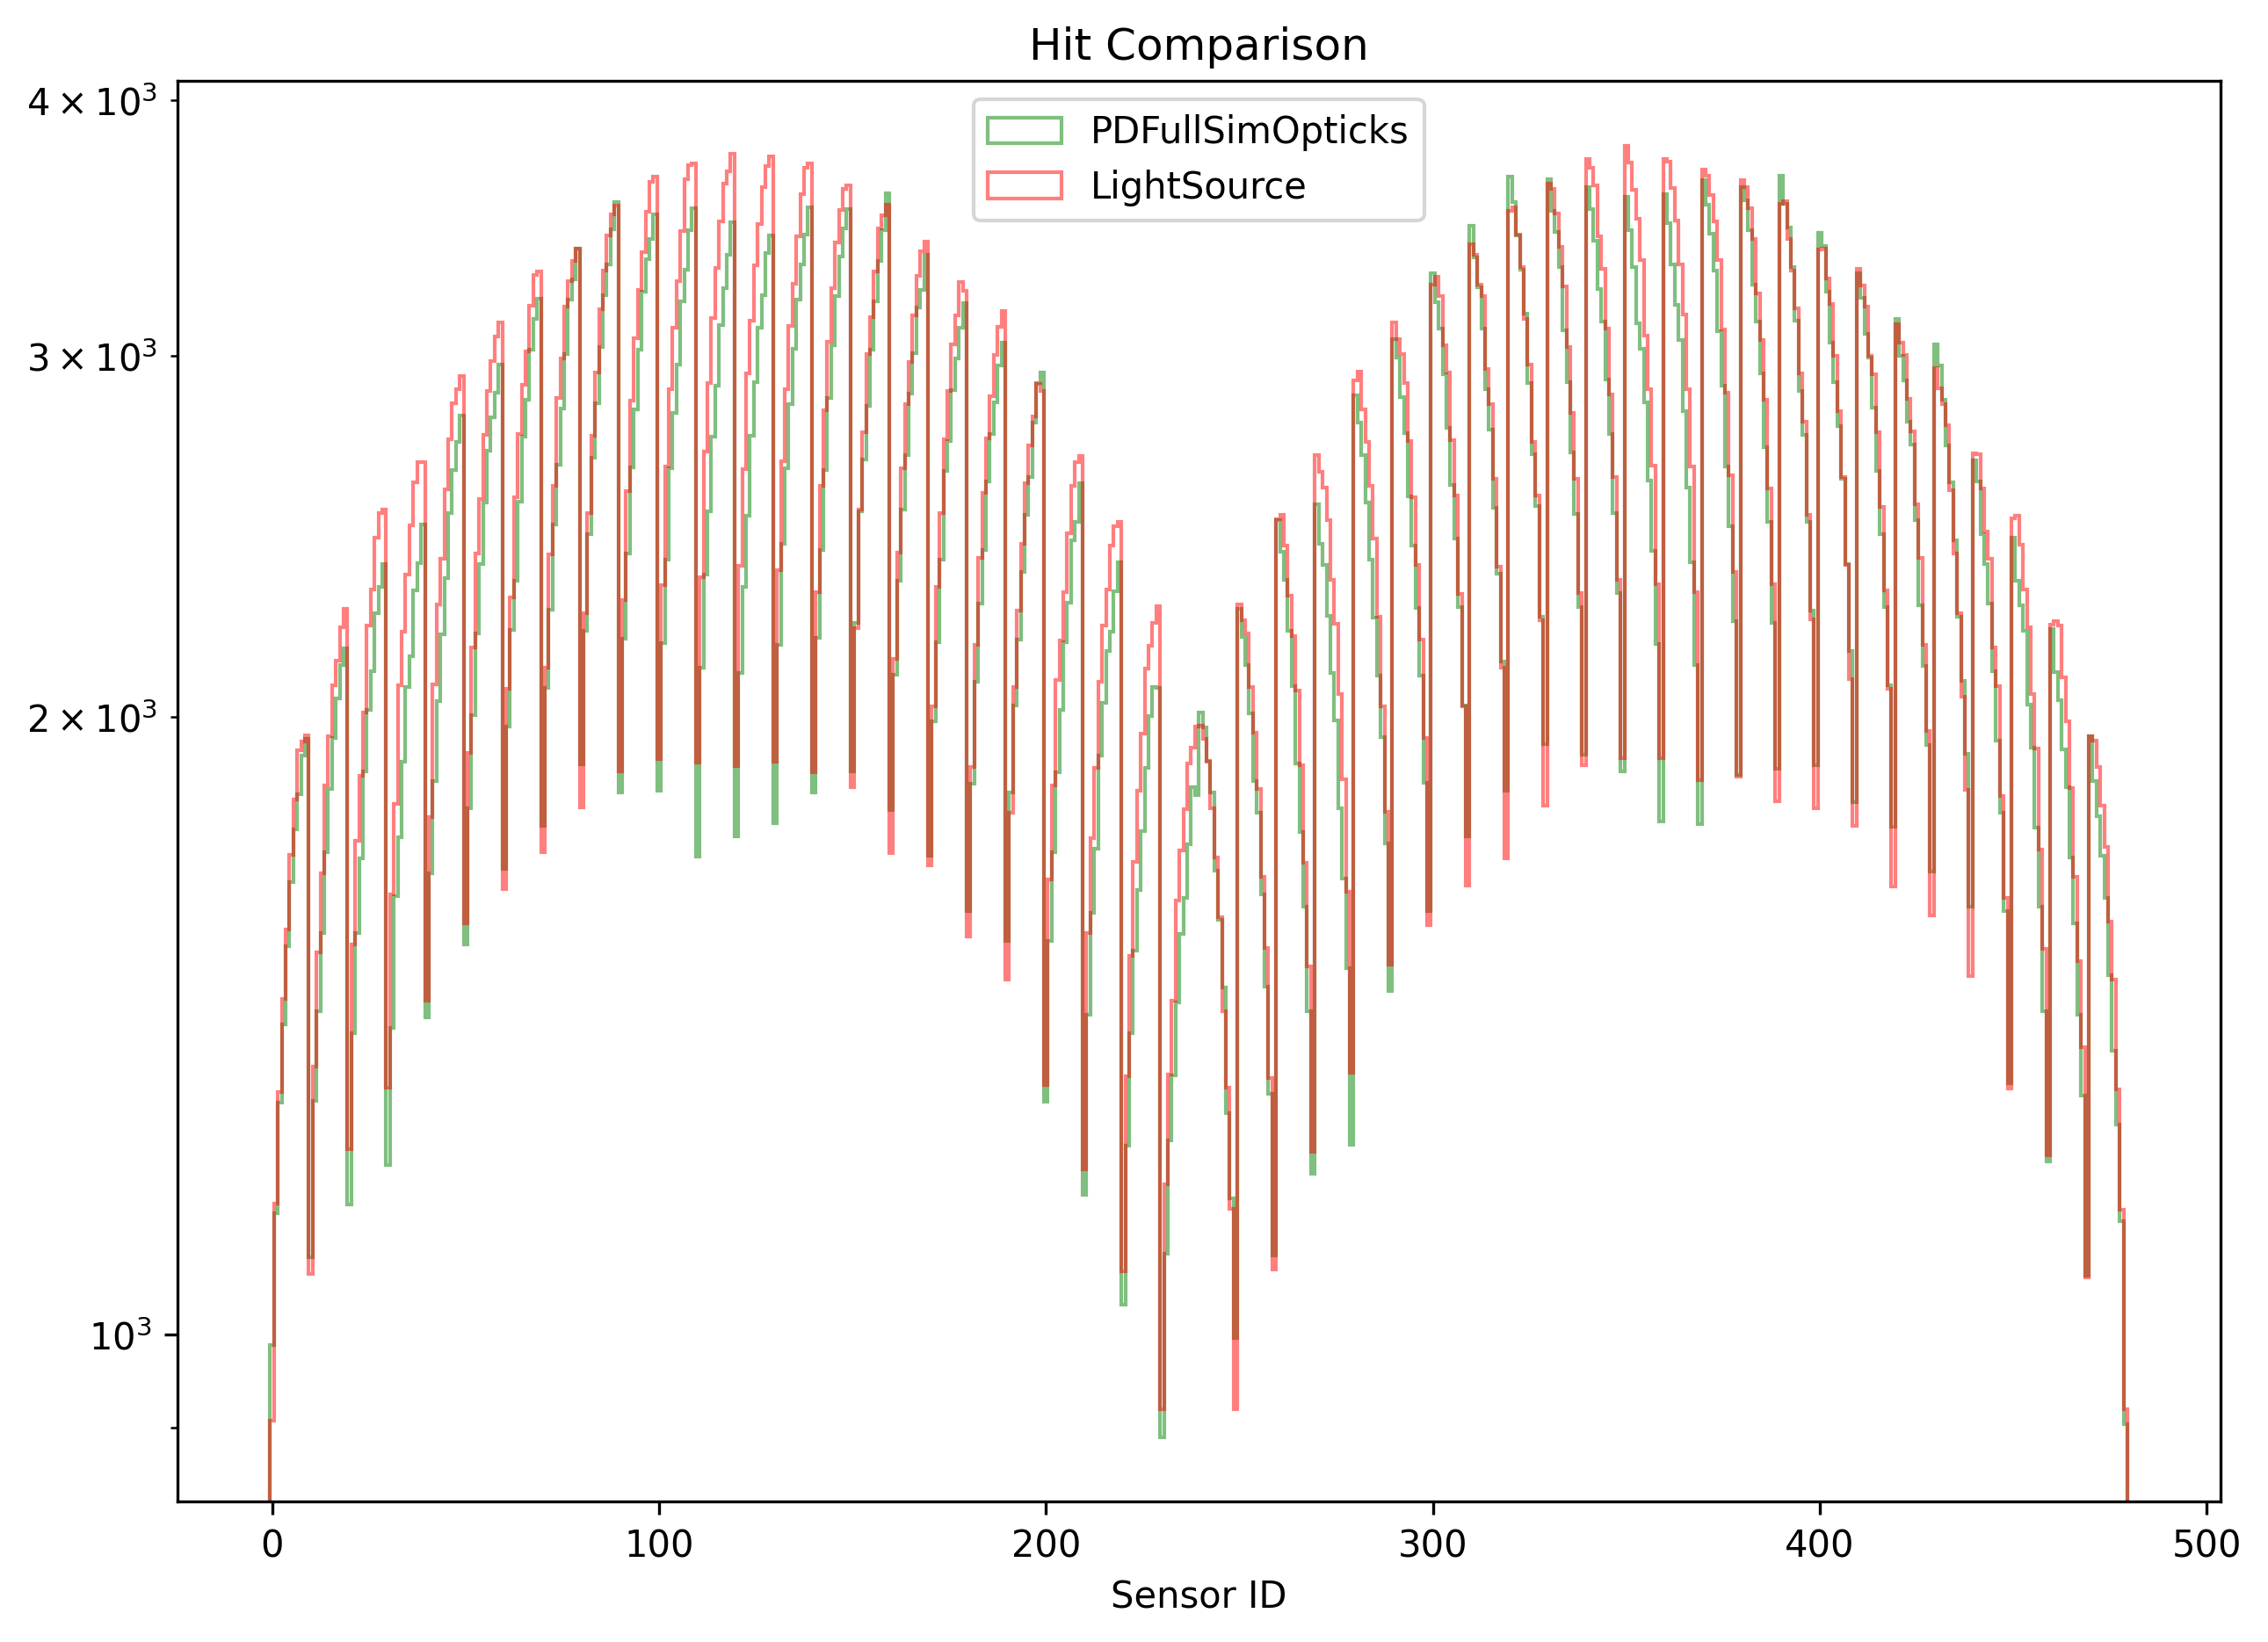

In [17]:
vismin = min(OSensorID.min(), G4SensorID.min())
vismax = max(OSensorID.max(), G4SensorID.max())
xbins = np.arange(vismin-0.5 , vismax+1.5 , 1)
plt.figure(figsize=(10,7),dpi=300)
plt.title("Hit Comparison")
plt.hist(OSensorID, bins=xbins, alpha=0.5, label="PDFullSimOpticks",histtype="step",color="green")
plt.hist(G4SensorID, bins=xbins, alpha=0.5, label="LightSource",histtype="step",color="red")
#plt.hist(OhitSensID, bins=xbins, alpha=0.5, label="Optickshits")
plt.legend()
plt.semilogy()
plt.xlabel("Sensor ID")


/tmp/rice/opticks/ipykernel_3399653/947498567.py:195: RuntimeWarning: divide by zero encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_3399653/947498567.py:197: RuntimeWarning: invalid value encountered in divide
  res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)


 Size Bin_Centers is 49
 Size result 49 min, max inf , 0.25
 Size res_err 49 min, max nan , nan


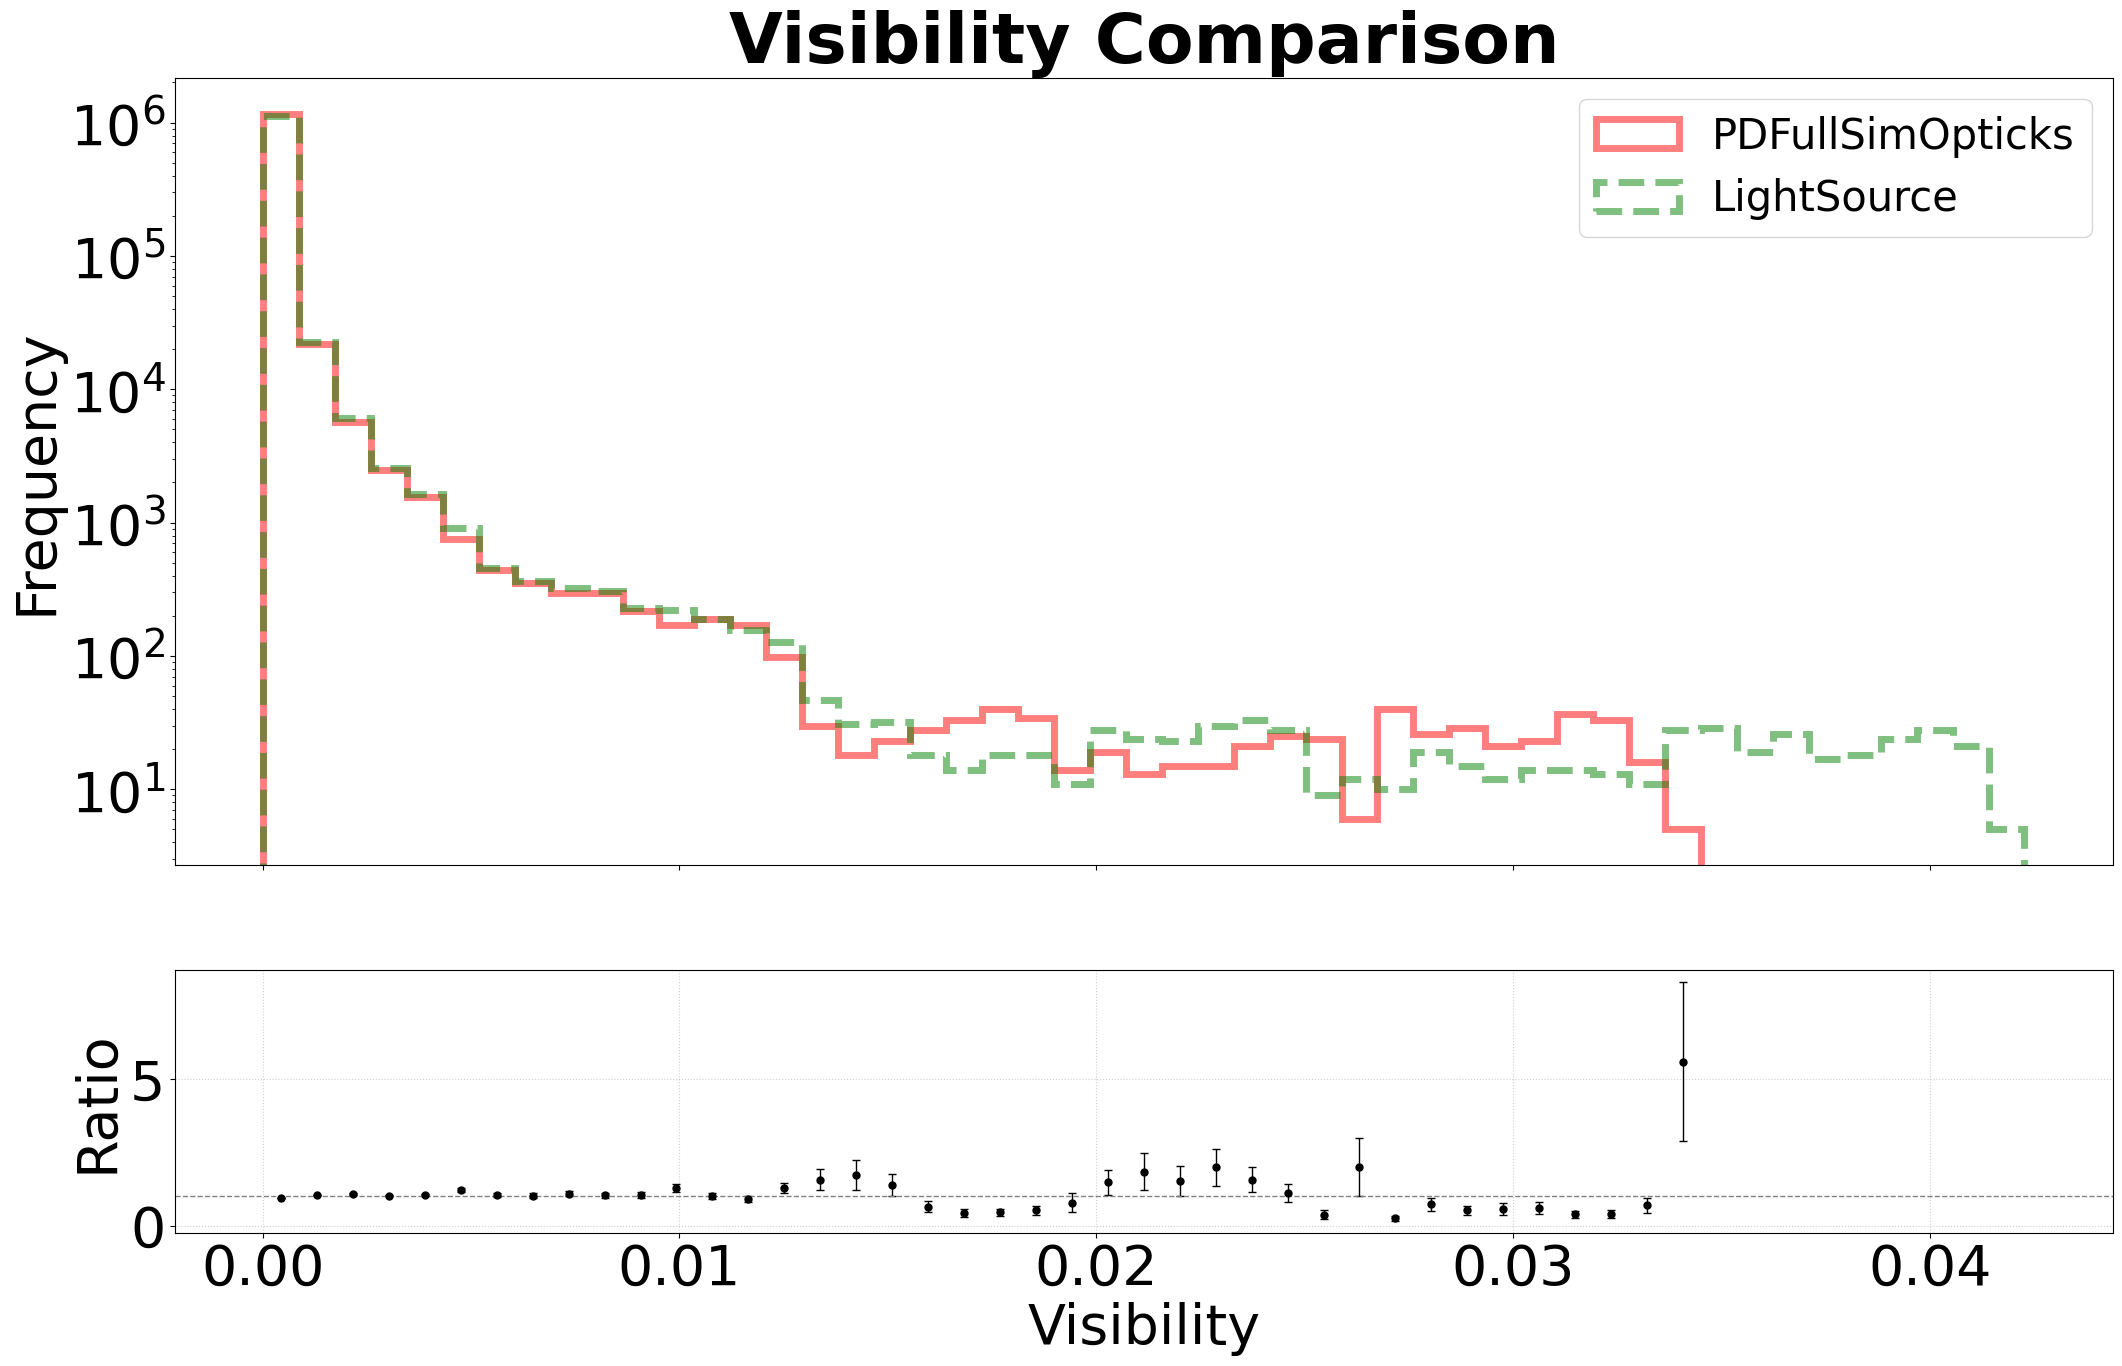

In [18]:
isSafeFiles=False
_=Plot1D_KDE(OVisibility,G4Visibility,"Visibility Comparision","Visibility Comparison",Binsize=50,labelx="Visibility",isPlottext=False,isHistType="",opacity=0.5,fontsize=30,width=5,lbls=["PDFullSimOpticks","LightSource"],tp="ratio")

 Size Bin_Centers is 479
 Size result 479 min, max 1.0881057268722467 , 0.8427399903521466
 Size res_err 479 min, max 0.05002290003919072 , 0.02146890849780326


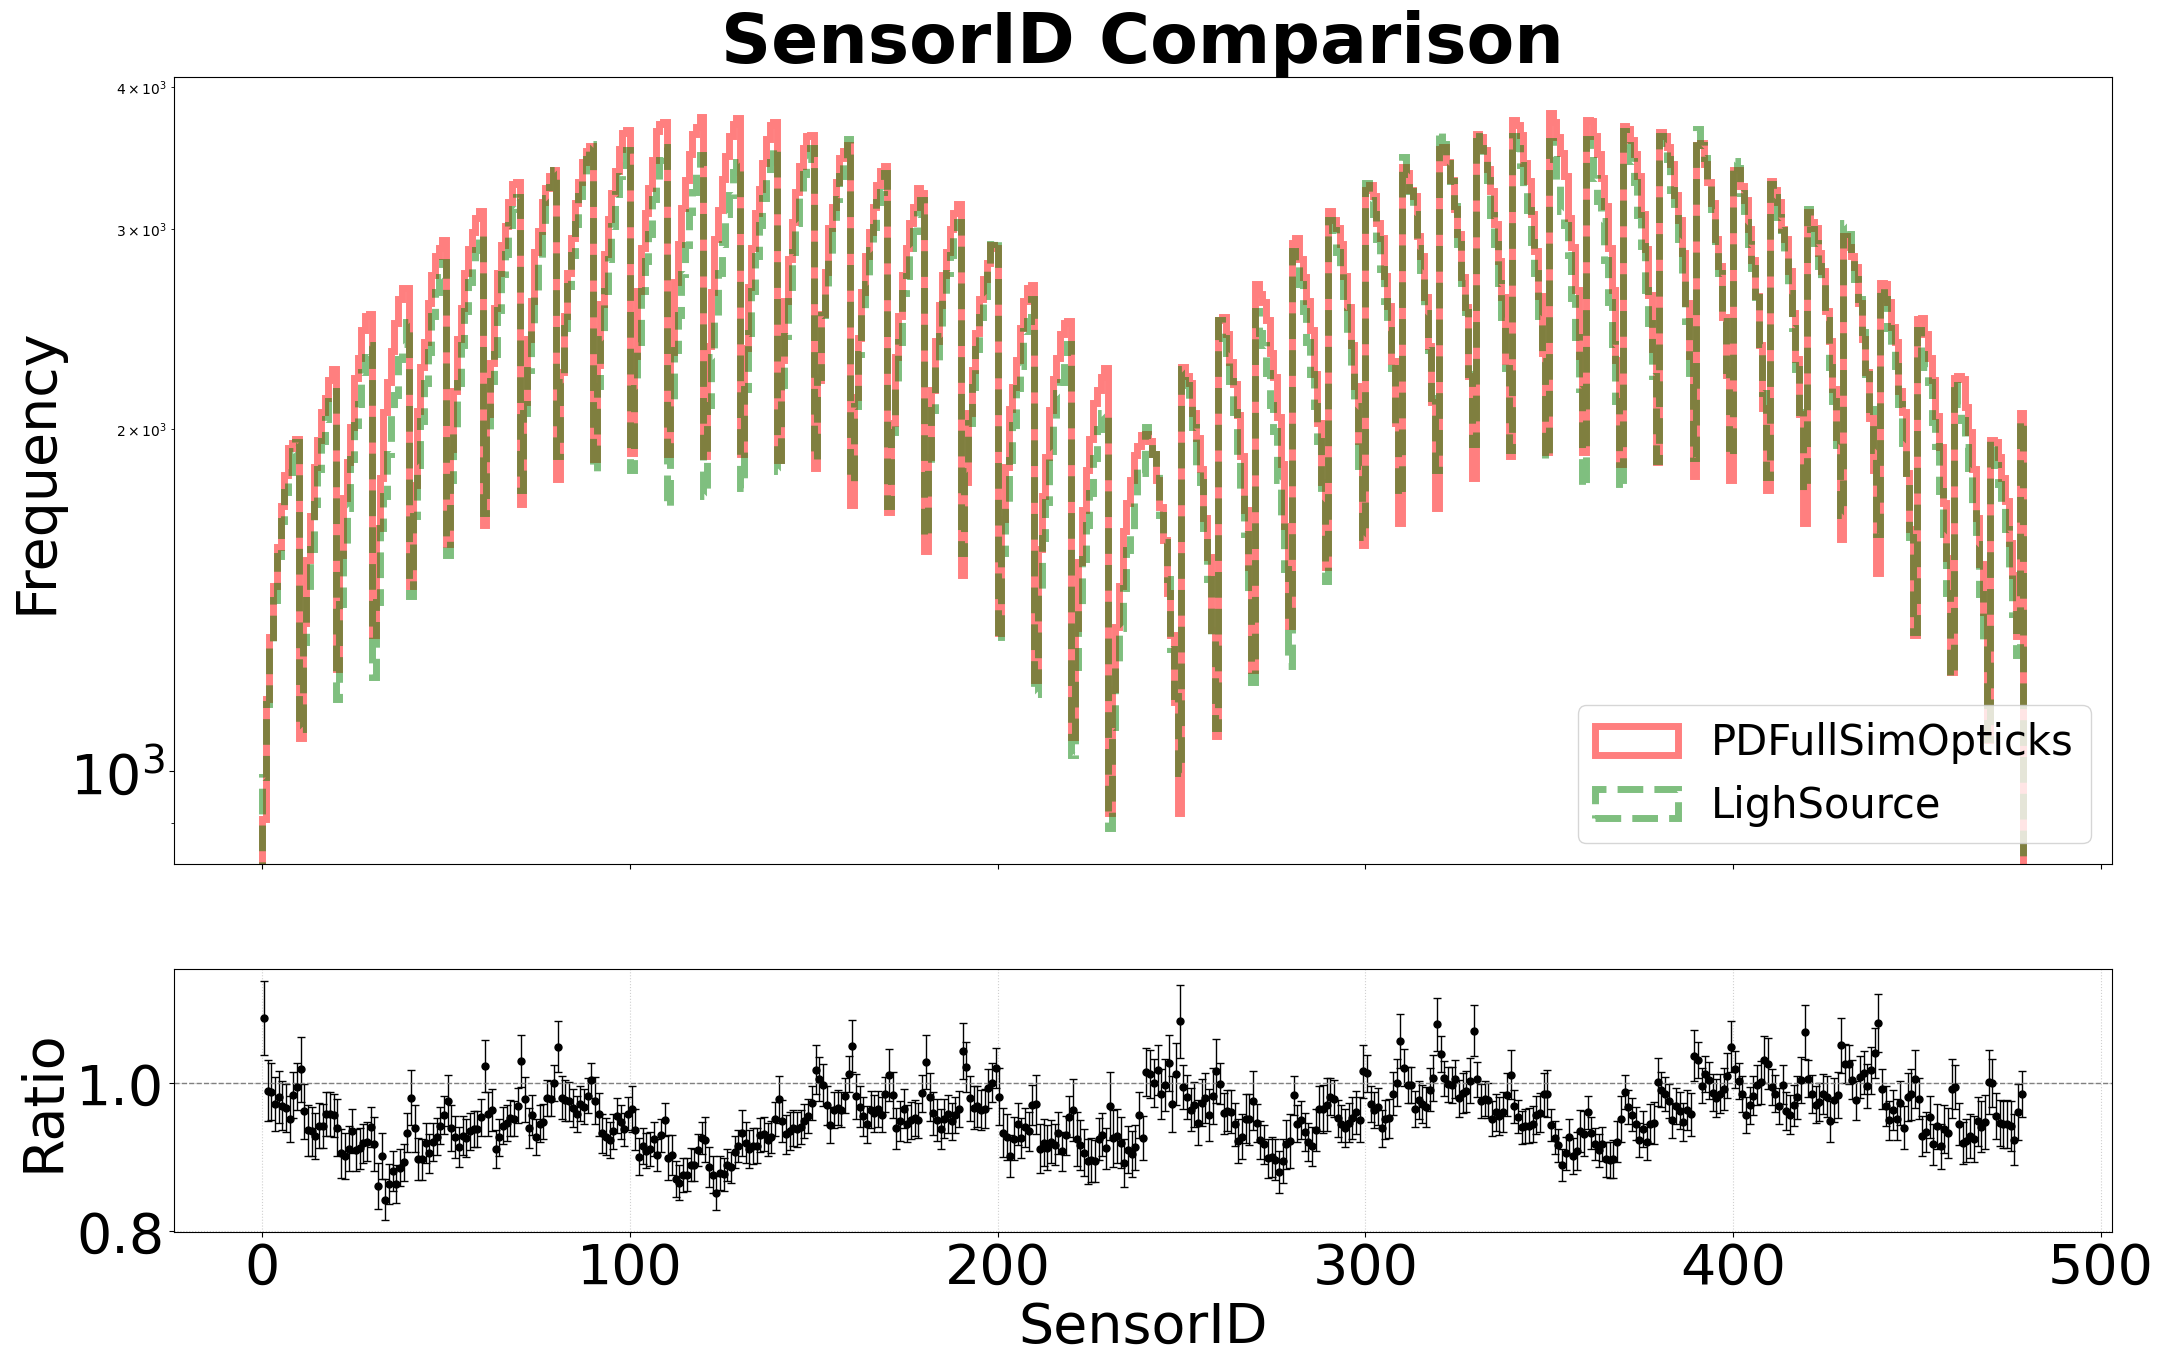

In [19]:
_=Plot1D_KDE(OSensorID,G4SensorID,"SensorID_Comparison","SensorID Comparison",Binsize=480,labelx="SensorID",isPlottext=False,isHistType="",opacity=0.5,fontsize=30,width=5,lbls=["PDFullSimOpticks","LighSource"],tp="ratio")

In [15]:
ox=file["opticks/OpticksHits/x"].array().to_numpy()
oy=file["opticks/OpticksHits/y"].array().to_numpy()
oz=file["opticks/OpticksHits/z"].array().to_numpy()
ot=file["opticks/OpticksHits/t"].array().to_numpy()

osid=file["opticks/OpticksHits/sensor_id"].array().to_numpy()
owavelength=file["opticks/OpticksHits/wavelength"].array().to_numpy()

In [16]:
c=5000
b=250

Zmin = min(oz.min(), G4Z.min())
Zmax = max(OptZ.max(), G4Z.max())
Ymin = min(OptY.min(), G4Y.min())
Ymax = max(OptY.max(), G4Y.max())
zbins = np.linspace(Zmin , Zmax ,b)
ybins = np.linspace(Ymin , Ymax , b)
fig,p=plt.subplots(1,2,dpi=250,figsize=(13,5))
p[0].set_title("Opticks")
h1=p[0].hist2d(OptZ,OptY,bins=[zbins,ybins],cmin=0,cmax=c,cmap="viridis",label="Opticks")
cbar1=fig.colorbar(h1[3])
cbar1.set_label("Photons", fontsize=12)
p[1].set_title("G4")
h2=p[1].hist2d(G4Z,G4Y,bins=[zbins,ybins],cmin=0,cmax=c,cmap="viridis",label="Geant4")
cbar2=fig.colorbar(h2[3])
cbar2.set_label("Photons", fontsize=12)
for i in range(0,2):
    p[i].set_xlabel("z(cm)")
    p[i].set_ylabel("y(cm)")


NameError: name 'G4Z' is not defined

In [ ]:
plt.figure(figsize=(8,4),dpi=150)
plt.title("Hits")
_=plt.hist2d(oz/10,oy/10,bins=500,cmin=0,cmax=2000)
plt.xlabel("z (cm)")
plt.ylabel("y (cm)")
plt.colorbar();

In [ ]:

initPhotons=file["generator/PhotonsGenerated"]
# load and flatten arrays
x = np.asarray(initPhotons["X"].array(library="np")).ravel()
y = np.asarray(initPhotons["Y"].array(library="np")).ravel()
z = np.asarray(initPhotons["Z"].array(library="np")).ravel()

# mask and downsample
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
pts = np.vstack((x[mask], y[mask], z[mask])).T
N = 100000  # keep this <= 100k for reasonable speed
if pts.shape[0] > N:
    idx = np.random.choice(pts.shape[0], N, replace=False)
    pts = pts[idx]

fig = plt.figure(figsize=(10,8))
plt.title("Primary Photon Production")
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=0.5, color="green", alpha=0.8)
ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)'); ax.set_zlabel('Z (cm)')
#plt.colorbar(sc, label='Z')
plt.tight_layout()
plt.savefig('cloud_3d.png', dpi=200)  # offscreen-friendly
plt.show()


In [ ]:
G4Time

In [ ]:
vismin = min(ot.min(), G4Time.min())
vismax = max(ot.max(), G4Time.max())
xbins = np.linspace(vismin , vismax , 80)
plt.hist(ot,color="green", bins=xbins, alpha=0.8,label="PDFullSimOpticks",histtype="step")
plt.hist(G4Time,color="red", bins=xbins,alpha=0.5,label="LightSource",histtype="step")
plt.xlabel("Time (ns)")
plt.semilogy()
plt.legend()
plt.show()